In [9]:
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask


print(f"[Line {inspect.currentframe().f_lineno}] ...  Done with cell. ")

[Line 13] n_cols in ConstantObjects: 21
[Line 15] n_cols: 21, n_rows: 18
[Line 26] n_cols in ConstantObjects: 21
[Line 28] gdf_tree_circles.shape: (378, 1)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907739, 38.150835)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907722, 38.151140)
x0 =  4246866.863321021
y0 =  546964.9960692101
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907036, 38.149684)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  4246989.3147608945
y0 =  546674.5010509877
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908725, 38.157014)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907594, 38.151076)
x0 =  4247044.974506292
y0 =  547177.2816059613
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908

In [12]:
import pandas as pd
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

from IPython.display import display, HTML
display(HTML("<style>.jp-OutputArea {max-height: 200px}</style>"))


rows = []  # collect per-date stats here

#ethiopia
startDate = "2021-10-01" #renaud  start date
startDate = "2021-09-30" #
endDate = "2022-06-30" # Renaud end date
endDate = "2022-02-28" # temp


dates = Utils.generate_date_range(startDate, endDate,  "%Y-%m-%d", 1)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
print ("*****  Constants.lat0, Constants.lon0 : ",Constants.lat0, Constants.lon0)
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

precip_df.head()
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")
                                 
#dates = Utils.generate_date_range("2025-06-16", "2025-06-17",  "%Y-%m-%d", 5)

# jan 12, no cloud directly over farm.
#Feb 11, lots of clouds over farm
ndmi_tile_tif=""
print(f"Cell [Line {inspect.currentframe().f_lineno}] ... dates = ",dates)
        
for date in dates:
    
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date = ",date)
    gndvi_tile_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "gndvi","tif")
    ndmi_tile_tif  = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi", "tif")
    rgb_tile_tif   = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb.uint8","tif")

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ndmi_tile_tif = ",ndmi_tile_tif)
    gdf_box = ConstantObjects.gdf_box_terreno_casa
    ndmi_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi-terreno-casa","tif")
    ndmi_plots_2_3_1A_1B_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "plots_2_3_1A_1B","tif")
    ndmi_casa_y_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "casa_y_vecino","tif")
    #ndmi_milpa_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "milpa_vecino","tif")

    b02_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B02","jp2")
    b03_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B03","jp2")
    b04_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B04","jp2")
    if os.path.exists(b02_terreno_casa_jp2) and os.path.exists(b03_terreno_casa_jp2) and os.path.exists(b04_terreno_casa_jp2):
        print(f"[Line {inspect.currentframe().f_lineno}] ... found all three of B02,B03, and B04 .jp2 images. Moving forward. ")
    else:
        print(f"[Line {inspect.currentframe().f_lineno}] ... will have to try the next date, because unable to find files:  ", b02_terreno_casa_jp2 ," , " , b03_terreno_casa_jp2," , " , b04_terreno_casa_jp2  )
        continue #If we do not have all three files for this date we should move on to the next date.
    green_vs_red_blue = np.nan
    rgb_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb-terreno-casa","tif")

    print(f"[Line {inspect.currentframe().f_lineno}] ... ndmi_terreno_casa_tif = ",ndmi_terreno_casa_tif)

    
    #cloud_terreno_casa = Utils.estimate_cloud_fraction_rgb_over_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa,treat_zero_as_nodata=True)
    # add up red intensity
    b2_intensity_terreno_casa = Utils.crop_and_sum_intensity(b02_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b3_intensity_terreno_casa = Utils.crop_and_sum_intensity(b03_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b4_intensity_terreno_casa = Utils.crop_and_sum_intensity(b04_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b2_norm_reflectance_terreno_casa = b2_intensity_terreno_casa["sum"]/b2_intensity_terreno_casa["valid_pixels"]
    b3_norm_reflectance_terreno_casa = b3_intensity_terreno_casa["sum"]/b3_intensity_terreno_casa["valid_pixels"]
    b4_norm_reflectance_terreno_casa = b4_intensity_terreno_casa["sum"]/b4_intensity_terreno_casa["valid_pixels"]
    red_green_blue_average = (b2_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa)/3 
    #SCF continue here..
    cloudy =0
    if (red_green_blue_average) > 1650:  cloudy = 1

    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_terreno_casa, ndmi_terreno_casa_tif) ")
    stats_terreno_casa = {
        "count_valid": 0,
        "mean": float("nan"),
        "median": float("nan"),
    }
    stats_casa_y_vecino = stats_terreno_casa

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")
    if not cloudy: stats_casa_y_vecino  = Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_casa_y_vecino , ndmi_casa_y_vecino_tif)  

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    print("Avg NDMI over AOI plots 4,5:", stats_casa_y_vecino["mean"])
  
    print(f"[Line {inspect.currentframe().f_lineno}] ...  ")
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    ndmi_plots_4_5_stats       =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      ndmi_tile_tif, "ndmi_plots_4_5",       date, cloudy)
    ndmi_plots_2_3_1A_1B_stats =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,ndmi_tile_tif, "ndmi_plots_2_3_1A_1B", date, cloudy)
    ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
    #ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
    ndmi_milpa_vecino_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,   ndmi_tile_tif, "ndmi_milpa_vecino",    date, cloudy)
    ndmi_terreno_casa_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_terreno_casa,   ndmi_tile_tif, "ndmi_terreno_casa",    date, cloudy)
    gndvi_plots_4_5_stats      =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      gndvi_tile_tif,"gndvi_plots_4_5",      date, cloudy)
    gndvi_plots_2_3_1A_1B_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,gndvi_tile_tif,"gndvi_plots_2_3_1A_1B",date, cloudy)
    #gndvi_milpa1_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa1,gndvi_tile_tif,"gndvi_milpa1",date, cloudy)
    gndvi_milpa1_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,gndvi_tile_tif,"gndvi_milpa1",date, cloudy)

    gndvi_milpa_vecino_stats   =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,gndvi_tile_tif,"gndvi_milpa_vecino",date, cloudy)

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_4_5_stats.get(mean,   np.nan) = ",gndvi_plots_4_5_stats.get("mean",   np.nan))
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_2_3_1A_1B_stats.get(mean,   np.nan) = ",gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan))

    #gndvi_reference = gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan)
    #ndmi_reference  = ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan)
    gndvi_reference = gndvi_milpa_vecino_stats.get("mean",   np.nan)
    ndmi_reference  = ndmi_milpa_vecino_stats.get("mean",   np.nan)
    
    rows.append({
        "date": date,
        "ndmi_terreno_casa":      ndmi_terreno_casa_stats.get("mean", np.nan),
        # Now making measurements relative to milpa_vecino
        "gndvi_plots_4_5":        gndvi_plots_4_5_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_plots_2_3_1A_1B":  gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_milpa1":           gndvi_milpa1_stats.get("mean",   np.nan)-gndvi_reference,

        "gndvi_milpa_vecino":     gndvi_milpa_vecino_stats.get("mean",   np.nan)-gndvi_reference,
        
        "ndmi_plots_4_5":         ndmi_plots_4_5_stats.get ("mean",   np.nan)-ndmi_reference,
        "ndmi_plots_2_3_1A_1B":   ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-ndmi_reference,
        "ndmi_milpa1":            ndmi_milpa1_stats.get("mean",   np.nan)-ndmi_reference,

        "ndmi_milpa_vecino":      ndmi_milpa_vecino_stats.get("mean",   np.nan)-ndmi_reference,
        
        "red": b2_norm_reflectance_terreno_casa,
        "green": b3_norm_reflectance_terreno_casa,
        "blue": b4_norm_reflectance_terreno_casa,
        "red_green_blue_average": red_green_blue_average,
        "cloudy" : cloudy *1

    })    
    print(f"[Line {inspect.currentframe().f_lineno}] ... Just appended to rows, an entry with date = ",date)
    print(f"[Cell Line {inspect.currentframe().f_lineno}] ... b2_intensity_terreno_casa[sum]  ",b2_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b3_intensity_terreno_casa[sum]  ",b3_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b4_intensity_terreno_casa[sum]  ",b4_intensity_terreno_casa["sum"])
    #print(f"Cell [Line {inspect.currentframe().f_lineno}] ... stats_milpa_vecino.get(mean,   np.nan)  ",stats_milpa_vecino.get("mean",   np.nan))

    #Utils.show_ndmi_moist(ndmi_terreno_casa_tif, scale=12)
    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa, rgb_terreno_casa_tif)  ")
 
    #Utils.show_tif_fit(rgb_terreno_casa_tif, scale=12, cmap="gray")
    print(f"[Line {inspect.currentframe().f_lineno}] ... ")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")

[Line 13] n_cols in ConstantObjects: 21
[Line 15] n_cols: 21, n_rows: 18
[Line 26] n_cols in ConstantObjects: 21
[Line 28] gdf_tree_circles.shape: (378, 1)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907739, 38.150835)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907722, 38.151140)
x0 =  4246866.863321021
y0 =  546964.9960692101
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907036, 38.149684)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  4246989.3147608945
y0 =  546674.5010509877
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908725, 38.157014)
x0 =  4246989.3147608945
y0 =  547032.0335418215
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.907594, 38.151076)
x0 =  4247044.974506292
y0 =  547177.2816059613
draw_grid_box : dx =  5
draw_grid_box : dy =  4
📍 Center of box: (4.908

[Line 29] ...   
*****  Constants.lat0, Constants.lon0 :  4.908058823095451 38.15135412942004
[Line 1301] ...   
[Line 1306] ...   
[Line 1309] ... pd.to_datetime(d[time])   DatetimeIndex(['2021-09-30', '2021-10-01', '2021-10-02', '2021-10-03',
               '2021-10-04', '2021-10-05', '2021-10-06', '2021-10-07',
               '2021-10-08', '2021-10-09',
               ...
               '2022-02-19', '2022-02-20', '2022-02-21', '2022-02-22',
               '2022-02-23', '2022-02-24', '2022-02-25', '2022-02-26',
               '2022-02-27', '2022-02-28'],
              dtype='datetime64[ns]', length=152, freq=None)
[Line 1310] ... d[precipitation_sum]   [0.6, 1.0, 0.0, 4.4, 4.5, 18.4, 0.0, 1.1, 1.1, 0.7, 0.7, 0.3, 4.7, 0.6, 0.4, 0.1, 0.3, 0.7, 0.4, 1.9, 3.1, 1.4, 0.6, 1.3, 0.0, 3.0, 1.0, 1.4, 2.0, 1.6, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.5, 2.8, 1.7, 5.7, 1.1, 0.0, 0.1, 1.7, 1.2, 0.9, 0.4, 2.0, 1.5, 0.1, 0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 3.1, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

ValueError: AOI does not overlap the raster (check CRS/location).

In [6]:
# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)    

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df["date"] = pd.to_datetime(df["date"]).dt.normalize()

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)


df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#df = pd.DataFrame(rows)
print(df.columns.tolist())
print(df.head())
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#Borana University, Ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"

def to_mx_date(col):
    return pd.to_datetime(col, utc=True).dt.tz_convert("America/Mexico_City").dt.normalize()

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# --- existing: daily precip
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
p = precip_df.copy()
p["date"] = p["date"].dt.tz_localize(None)
#p["date"] = pd.to_datetime(p["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

temp_df = Utils.daily_temp_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
t = temp_df.copy()
t["date"] = pd.to_datetime(t["date"]).dt.tz_localize(None)
#t["date"] = pd.to_datetime(t["date"]).dt.normalize()
p = p.merge(t, on="date", how="left").sort_values("date")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#p = p.sort_values("date")

# align daily precip with sparse NDMI, for excel:
out = p.merge(df, on="date", how="left")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# save for Excel
out.to_csv("daily_table.csv", index=False)
# or
# out.to_excel("daily_table.xlsx", index=False)
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")


[Cell Line 4] .. df =            date  ndmi_terreno_casa  gndvi_plots_4_5  gndvi_plots_2_3_1A_1B  \
0   2022-01-03                NaN              NaN                    NaN   
1   2022-01-08           0.042235         0.106388               0.016433   
2   2022-01-13                NaN              NaN                    NaN   
3   2022-01-18           0.056051        -0.038229              -0.022703   
4   2022-01-23          -0.020437         0.049109               0.024126   
5   2022-01-28                NaN              NaN                    NaN   
6   2022-02-02           0.032361         0.020106               0.010327   
7   2022-02-07                NaN              NaN                    NaN   
8   2022-02-12                NaN              NaN                    NaN   
9   2022-02-17           0.047580         0.044321               0.043651   
10  2022-02-22           0.075780         0.060372               0.062818   
11  2022-02-27                NaN              NaN   

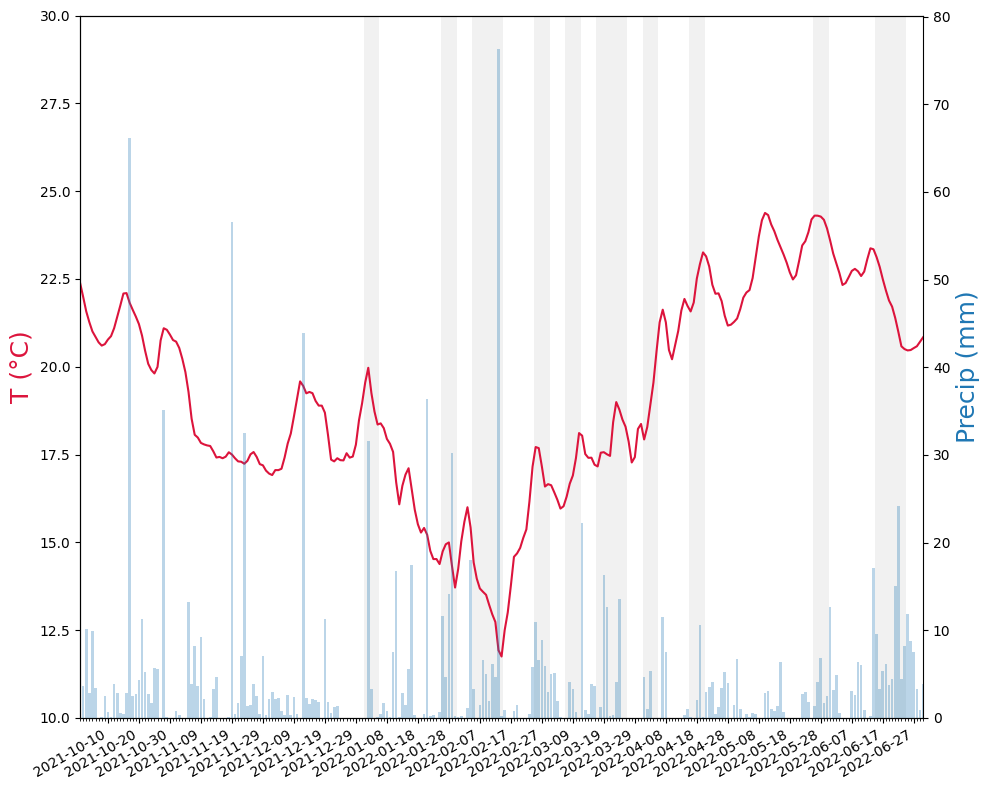

In [8]:
import matplotlib
import MatPlotLibUtils
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#importlib.reload(MatPlotLibUtils)
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(matplotlib)

import pandas

#warmDryStart2025 = pandas.to_datetime("2025-03-15")
#warmDryEnd2025   = pandas.to_datetime("2025-05-18") 
display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, ax = plt.subplots(figsize=(10, 8))
#ax=axes


minTemp = 10
maxTemp = 30
myfontsize = 18
#ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax.bar(df["date"], df["cloudy"].fillna(0)*maxTemp,color="lightgrey",
        width=pd.Timedelta("5D"), alpha=0.3, label="Cloudy")
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
#ax.set_ylabel("NDMI")
#ax.legend(loc="upper center")
ax.set_frame_on(True); ax.patch.set_visible(False)

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
# Precip (second right axis; ALL daily bars)
ax2.bar(p["date"], p["precip_mm"].fillna(0),
        width=pd.Timedelta("0.85D"), alpha=0.3, label="Precip (mm)",color=precip_color)


#axes[2].set_ylabel("NDMI (Moisture)",fontsize = myfontsize)



# horizontal line
#start = pd.to_datetime("2024-03-01")
#end   = pd.to_datetime("2024-05-31")

# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
ax.set_xlim(xmin, xmax)


ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))   # tick every 5 days
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))



fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("temp_precipitation_plot.png", dpi=300, bbox_inches="tight")